<a href="https://colab.research.google.com/github/Nazmul142965/Things-I-learned/blob/main/2023100000130_NazmulHasanipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

👇 Please upload your Input Image:


Saving Input_image.jpg to Input_image (1).jpg
Processing operations (please wait a moment)...
✅ Processing finished successfully!


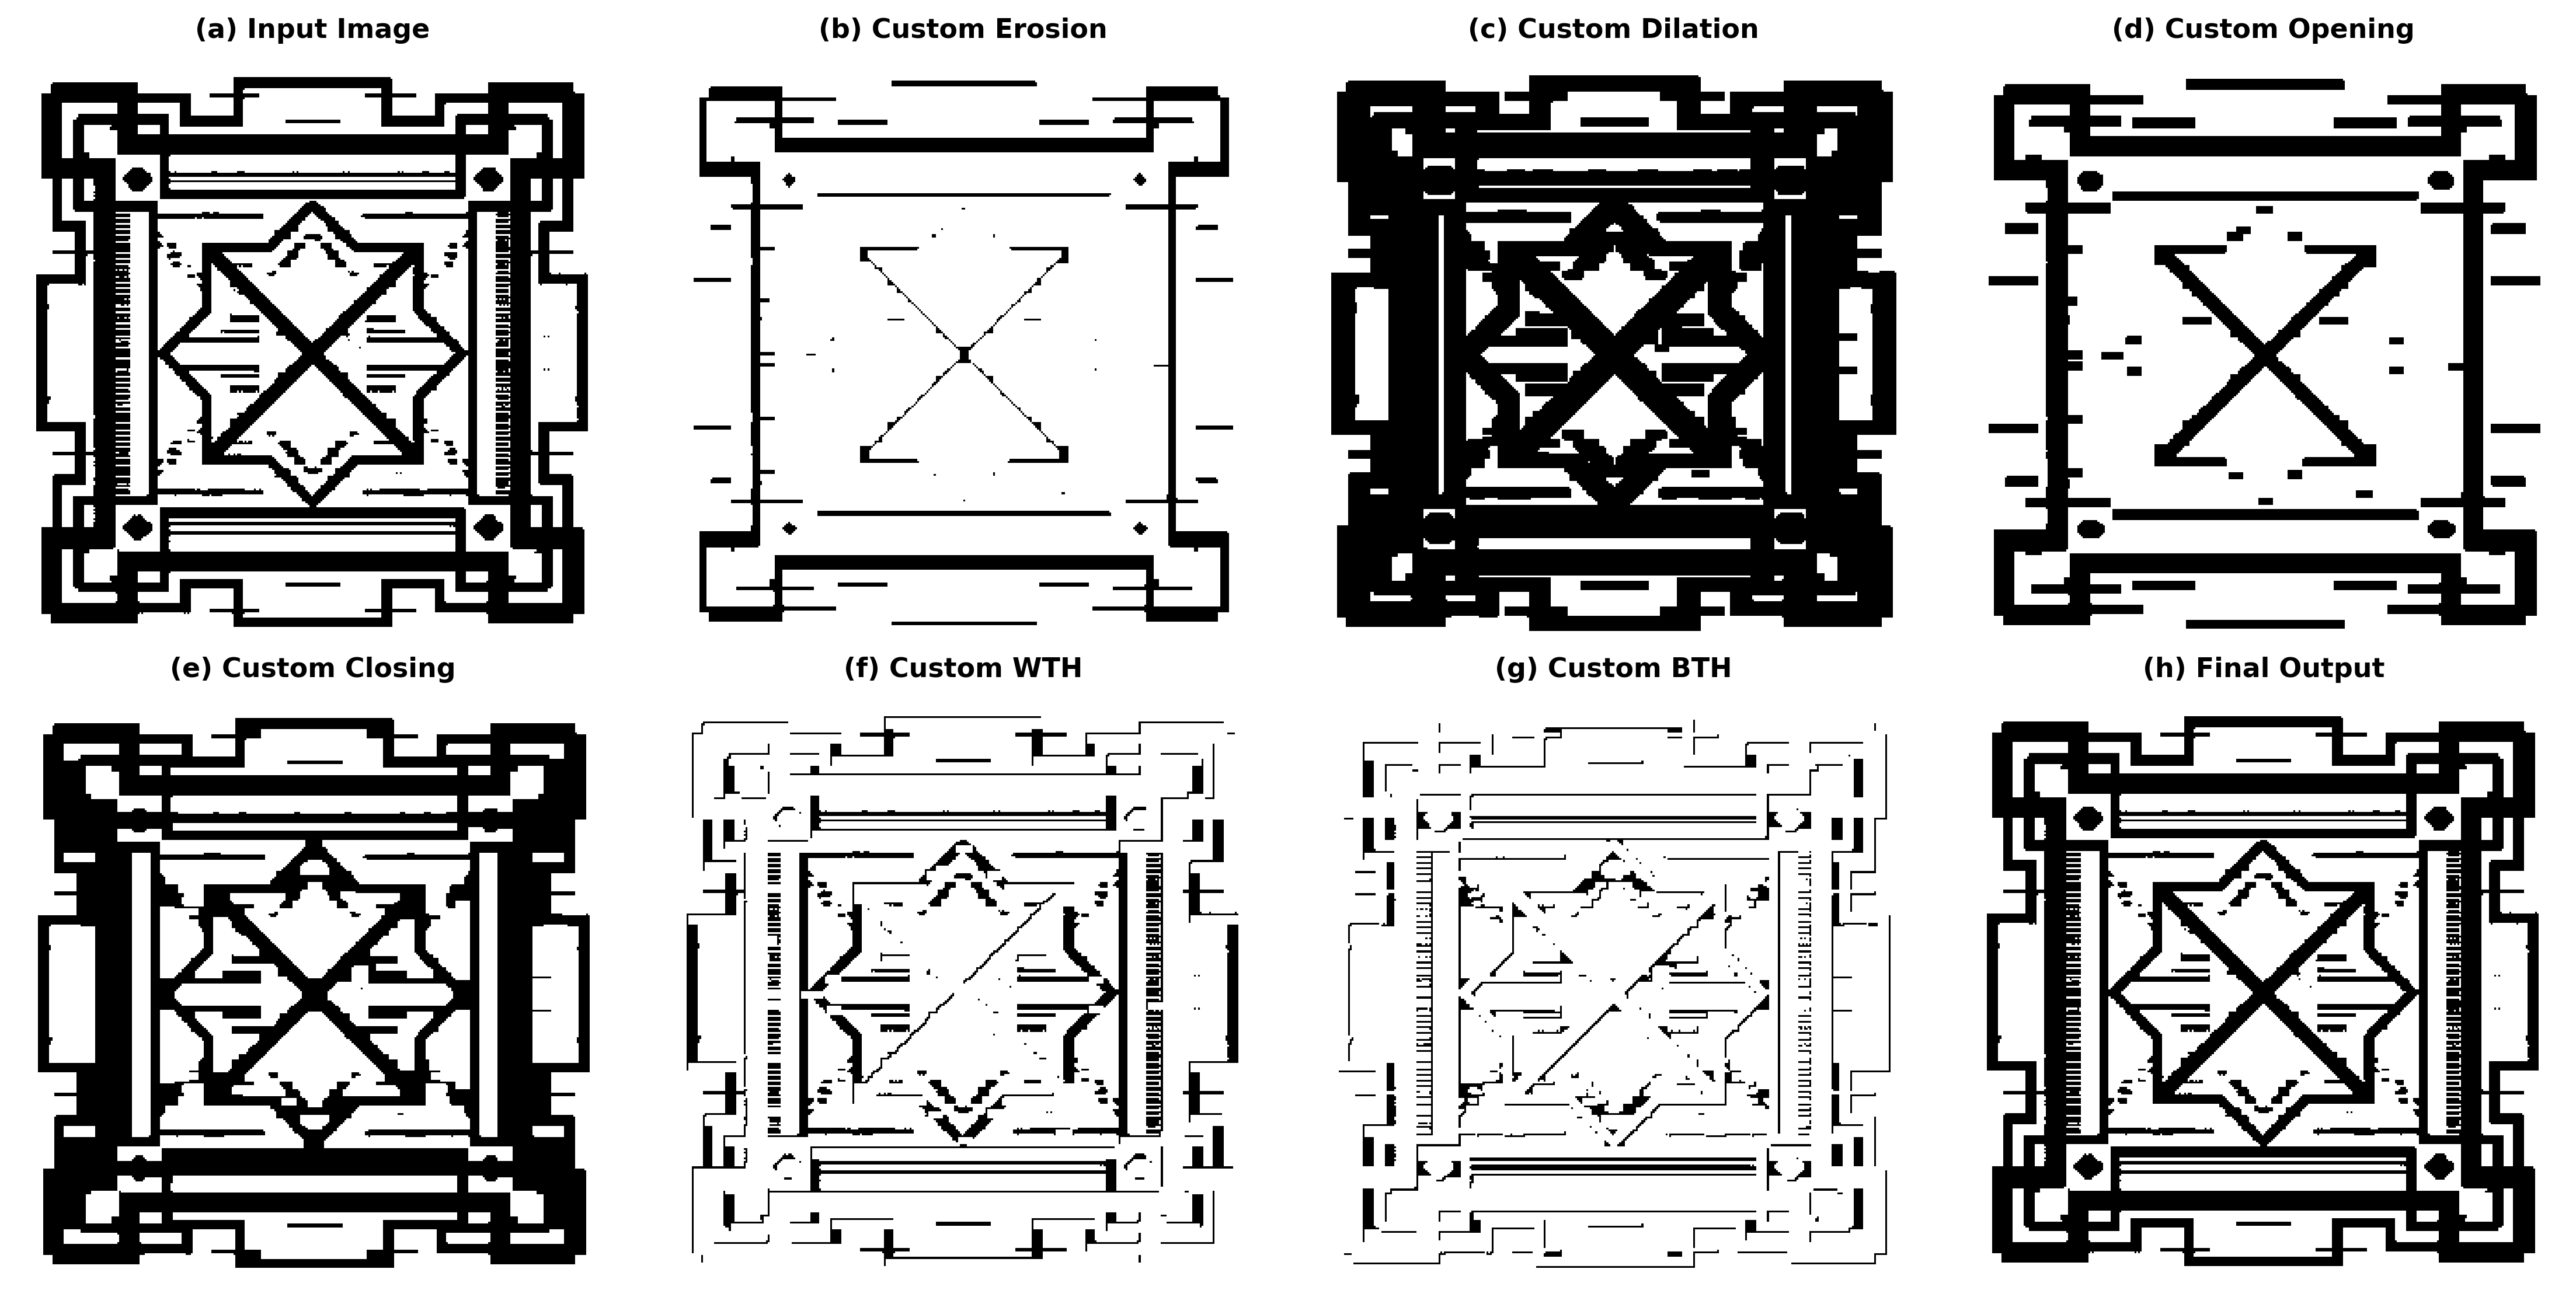

📁 Output files saved to Colab files panel:
 - 'Input_Image.png' (For Section 5 of your report)
 - 'All_Outputs_Grid.png' (For Section 6 of your report)


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os


# STEP 1: LOAD THE INPUT IMAGE AND PROPER BINARIZATION

from google.colab import files

print("👇 Please upload your Input Image:")
uploaded = files.upload()

# Automatically get the file name of the uploaded image
image_filename = list(uploaded.keys())[0]
img_input = cv2.imread(image_filename, cv2.IMREAD_GRAYSCALE)

# Using THRESH_BINARY_INV: Black pattern becomes Foreground (255) and White background becomes (0)
_, img_binary = cv2.threshold(img_input, 127, 255, cv2.THRESH_BINARY_INV)
# Using THRESH_BINARY_INV: Black pattern becomes Foreground (255) and White background becomes (0)
_, img_binary = cv2.threshold(img_input, 127, 255, cv2.THRESH_BINARY_INV)


# STEP 2: CUSTOM MORPHOLOGICAL FUNCTIONS FROM SCRATCH (NO BUILT-IN FUNCTIONS)

def create_rectangular_se(height, width):
    """Creates a custom rectangular structuring element filled with 1s."""
    return np.ones((height, width), dtype=np.uint8)


def custom_erode(image, kernel):
    """
    Custom Erosion implementation.
    Shrinks the foreground (255). A pixel remains 255 ONLY IF all pixels under kernel match.
    """
    img_h, img_w = image.shape
    k_h, k_w = kernel.shape

    pad_h = k_h // 2
    pad_w = k_w // 2

    # Pad image with 0 (background) for erosion
    padded_img = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    eroded_img = np.zeros_like(image)

    for r in range(img_h):
        for c in range(img_w):
            region = padded_img[r:r+k_h, c:c+k_w]
            if np.all(region[kernel == 1] == 255):
                eroded_img[r, c] = 255
            else:
                eroded_img[r, c] = 0

    return eroded_img


def custom_dilate(image, kernel):
    """
    Custom Dilation implementation.
    Expands the foreground (255). A pixel becomes 255 IF AT LEAST ONE pixel under kernel is 255.
    """
    img_h, img_w = image.shape
    k_h, k_w = kernel.shape

    pad_h = k_h // 2
    pad_w = k_w // 2

    # Pad image with 0 (background) for dilation
    padded_img = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    dilated_img = np.zeros_like(image)

    for r in range(img_h):
        for c in range(img_w):
            region = padded_img[r:r+k_h, c:c+k_w]
            if np.any(region[kernel == 1] == 255):
                dilated_img[r, c] = 255
            else:
                dilated_img[r, c] = 0

    return dilated_img


def custom_opening(image, kernel):
    """Opening = Dilation(Erosion(Image))"""
    eroded = custom_erode(image, kernel)
    return custom_dilate(eroded, kernel)


def custom_closing(image, kernel):
    """Closing = Erosion(Dilation(Image))"""
    dilated = custom_dilate(image, kernel)
    return custom_erode(dilated, kernel)


def custom_subtract(img1, img2):
    """Custom pixel-wise subtraction clipped to binary range [0, 255] without underflow."""
    result = img1.astype(np.int16) - img2.astype(np.int16)
    return np.clip(result, 0, 255).astype(np.uint8)


def custom_add(img1, img2):
    """Custom pixel-wise addition clipped to binary range [0, 255]."""
    result = img1.astype(np.int16) + img2.astype(np.int16)
    return np.clip(result, 0, 255).astype(np.uint8)


# STEP 3: RUN FULL PIPELINE (MATHEMATICAL FORMULA FROM THE PAPER)

# Define optimal 4x8 rectangular Structuring Element
se_4x8 = create_rectangular_se(4, 8)

print("Processing operations (please wait a moment)...")

# 1. Basic Operations
img_erosion = custom_erode(img_binary, se_4x8)
img_dilation = custom_dilate(img_binary, se_4x8)

# 2. Opening & Closing
img_opening = custom_opening(img_binary, se_4x8)
img_closing = custom_closing(img_binary, se_4x8)

# 3. Top-Hat Transformations
# WTH = Image - Opening
img_wth = custom_subtract(img_binary, img_opening)

# BTH = Closing - Image
img_bth = custom_subtract(img_closing, img_binary)

# 4. Final Output Formula: Output = IM + WTH - BTH
temp_step = custom_add(img_binary, img_wth)
final_output = custom_subtract(temp_step, img_bth)

print("✅ Processing finished successfully!")


# STEP 4: DISPLAY AND EXPORT CLEAN RESULTS FOR REPORT

# 1. Save single Input Image for Section 5 of the report
cv2.imwrite('Input_Image.png', 255 - img_binary)

# 2. Prepare 2x4 comparison grid with white background and black patterns
titles = [
    "(a) Input Image", "(b) Custom Erosion", "(c) Custom Dilation", "(d) Custom Opening",
    "(e) Custom Closing", "(f) Custom WTH", "(g) Custom BTH", "(h) Final Output"
]

images = [
    img_binary, img_erosion, img_dilation, img_opening,
    img_closing, img_wth, img_bth, final_output
]

plt.figure(figsize=(15, 7.5), dpi=300)

for i in range(8):
    plt.subplot(2, 4, i + 1)
    # Invert (255 - image) so all 8 images display cleanly with white background and black pattern
    display_img = 255 - images[i]
    plt.imshow(display_img, cmap='gray', vmin=0, vmax=255)
    plt.title(titles[i], fontsize=11, fontweight='bold', pad=8)
    plt.axis('off')

plt.tight_layout()
# Save the grid image for Section 6 of the report
plt.savefig('All_Outputs_Grid.png', bbox_inches='tight')
plt.show()

print("📁 Output files saved to Colab files panel:")
print(" - 'Input_Image.png' (For Section 5 of your report)")
print(" - 'All_Outputs_Grid.png' (For Section 6 of your report)")